# Barcelona Airbnb – Price Analysis

Analysis of how nightly price fluctuates across room type, minimum nights, host portfolio size, number of reviews, and district.


## 1. Učitavanje i prečišćavanje podataka


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi']   = 80
plt.rcParams['savefig.dpi']  = 150


df = pd.read_csv('listings_veci.csv', usecols=[
    'id', 'neighbourhood_group_cleansed', 'neighbourhood_cleansed',
    'room_type', 'price', 'minimum_nights',
    'number_of_reviews_ltm',
    'calculated_host_listings_count',
    'latitude', 'longitude',
    'accommodates', 'bedrooms', 'beds', 'bathrooms',  
    'review_scores_rating',                            
])

df = df.rename(columns={
    'neighbourhood_group_cleansed': 'neighbourhood_group',  #ostavljamo grupu neighbourhood zbog grafova posle, ovo je 10 grupa 10 delova grada
    'neighbourhood_cleansed':       'neighbourhood',
    'number_of_reviews_ltm':        'number_of_reviews'
})

# Posto je cena u csv u string formatu, moramo izvuci broj iz nje
df['price'] = pd.to_numeric(
    df['price'].str.replace('[$,]', '', regex=True), errors='coerce'
)
df = df.dropna(subset=['price', 'room_type'])
df = df[df['price'] > 0]

# Pomocu IQR, skidamo gornje i donje outliere, odnosno sve ispod 25. percentila i iznad 75. percentila
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
price_upper = Q3 + 1.5 * IQR
df = df[df['price'] <= price_upper]

# Prazne redove NaN punimo sa median vrednoscu
for col in ['bedrooms', 'beds', 'bathrooms', 'review_scores_rating']:
    df[col] = df[col].fillna(df[col].median())

# Racunamo udaljenost od centra Barselone (Placa de Catalyna) na osnovu latitude i longitude kolone iz CSV
CENTER_LAT, CENTER_LON = 41.3870, 2.1700
df['dist_center_km'] = np.sqrt(
    ((df['latitude']  - CENTER_LAT) * 111) ** 2 +
    ((df['longitude'] - CENTER_LON) * 111 * np.cos(np.radians(CENTER_LAT))) ** 2
)
df = df.drop(columns=['latitude', 'longitude'])

# Ordinal encoding for neighbourhood: rank each of 75 neighbourhoods by median price.
# Rank 1 = most expensive, rank 75 = cheapest. Single column instead of 75 one-hot columns.
neighbourhood_rank = df.groupby('neighbourhood')['price'].median().rank(ascending=False)
df['neighbourhood_rank'] = df['neighbourhood'].map(neighbourhood_rank)

# One-hot enkodiranje za tip sobe
df = pd.get_dummies(df, columns=['room_type'], prefix='room', drop_first=False)
room_cols = [c for c in df.columns if c.startswith('room_')]
df['room_type'] = df[room_cols].idxmax(axis=1).str.replace('room_', '', regex=False)

# Definisemo x osu za dijagrame 
df['min_nights_bucket'] = pd.cut(
    df['minimum_nights'],
    bins=[0, 1, 3, 7, 14, 30, 9999],
    labels=['1 night', '2-3 nights', '4-7 nights', '8-14 nights', '15-30 nights', '30+ nights']
)
df['reviews_bucket'] = pd.cut(
    df['number_of_reviews'],
    bins=[-1, 0, 3, 10, 20, 9999],
    labels=['No reviews', '1-3', '4-10', '11-20', '21+']
)
df['host_size_bucket'] = pd.cut(
    df['calculated_host_listings_count'],
    bins=[0, 1, 3, 10, 50, 9999],
    labels=['1 (Solo)', '2-3', '4-10', '11-50', '50+ (Agency)']
)

# Uradicemo log transformaciju za ova 3 parametra, posto je razlika izmedju avg i median jako velika u csv
# log1p = log(1 + x) dodamo kad je x = 0 posto je log(0) undefined
for col in ['minimum_nights', 'number_of_reviews', 'calculated_host_listings_count']:
    df[col] = np.log1p(df[col])

print(f'Učitani listinzi:  {len(df):,}')
print(f'Price range:       €{df["price"].min():.0f} – €{df["price"].max():.0f}')
print(f'Average price:     €{df["price"].mean():.2f}')
print(f'Median price:      €{df["price"].median():.2f}')
print(f'Distance range:    {df["dist_center_km"].min():.2f} – {df["dist_center_km"].max():.2f} km')
print(f'\n13 numeričkih parametara za korišćenje u modelu:')
numerical_cols = room_cols + [
    'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count',
    'dist_center_km', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'review_scores_rating', 'neighbourhood_rank'
]
print(numerical_cols)

Učitani listinzi:  14,535
Price range:       €9 – €432
Average price:     €142.72
Median price:      €123.00
Distance range:    0.02 – 8.38 km

13 numeričkih parametara za korišćenje u modelu:
['room_Entire home/apt', 'room_Hotel room', 'room_Private room', 'room_Shared room', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'dist_center_km', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'review_scores_rating', 'neighbourhood_rank']


## 2. Prosečna i medijalna cena smeštaja u Barseloni


In [13]:
summary = df['price'].describe().rename({
    'count': 'Count', 'mean': 'Mean (€)', '50%': 'Median (€)'
}).to_frame().T.round(2)
summary = summary[['Count', 'Mean (€)', 'Median (€)']]

summary.style.format('€{:.2f}', subset=['Mean (€)', 'Median (€)']).set_caption('Overall Price Distribution')

,Count,Mean (€),Median (€)
price,14535.000000,€142.72,€123.00


## 3. Cena po tipu sobe


,Count,Mean,Median
room_type,,,
Hotel room,47,€208.60,€200.00
Entire home/apt,"9,818",€172.20,€162.00
Private room,"4,568",€80.55,€62.00
Shared room,102,€58.20,€43.00


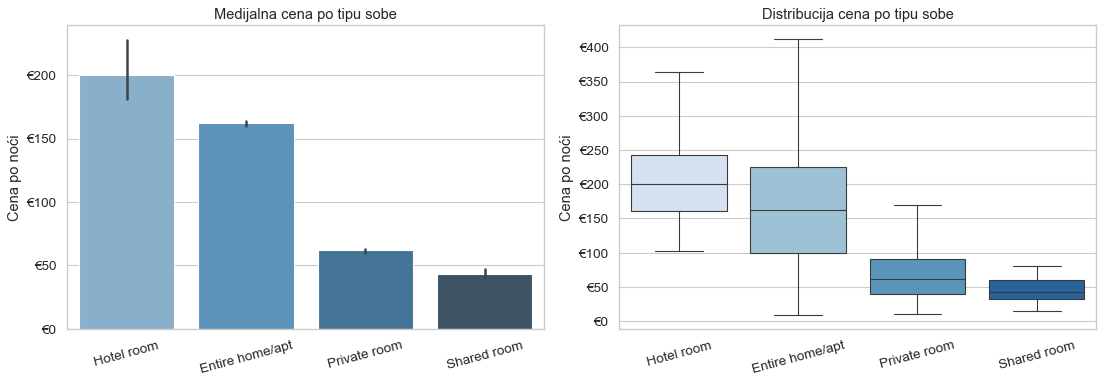

In [14]:
rt_stats = df.groupby('room_type')['price'].agg(
    Count='count', Mean='mean', Median='median'
).round(2).sort_values('Median', ascending=False)

display(rt_stats.style
    .background_gradient(subset=['Mean', 'Median'], cmap='Blues')
    .format({'Mean': '€{:.2f}', 'Median': '€{:.2f}', 'Count': '{:,}'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = rt_stats.index.tolist()
sns.barplot(data=df, x='room_type', y='price', estimator='median',
            order=order, palette='Blues_d', ax=axes[0])
axes[0].set_title('Medijalna cena po tipu sobe')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cena po noći')
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))

sns.boxplot(data=df[df['price'] < 600], x='room_type', y='price',
            order=order, palette='Blues', ax=axes[1], showfliers=False)
axes[1].set_title('Distribucija cena po tipu sobe')
axes[1].set_xlabel('')
axes[1].set_ylabel('Cena po noći')
axes[1].tick_params(axis='x', rotation=15)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))

plt.tight_layout()
plt.show()

## 4. Cena po broju minimalnih noći u smeštaju


,Count,Mean,Median
min_nights_bucket,,,
1 night,"4,334",€183.75,€183.00
2-3 nights,"3,133",€178.41,€172.00
4-7 nights,832,€184.94,€178.00
8-14 nights,30,€98.87,€68.00
15-30 nights,353,€86.91,€88.00
30+ nights,"5,853",€90.81,€77.00


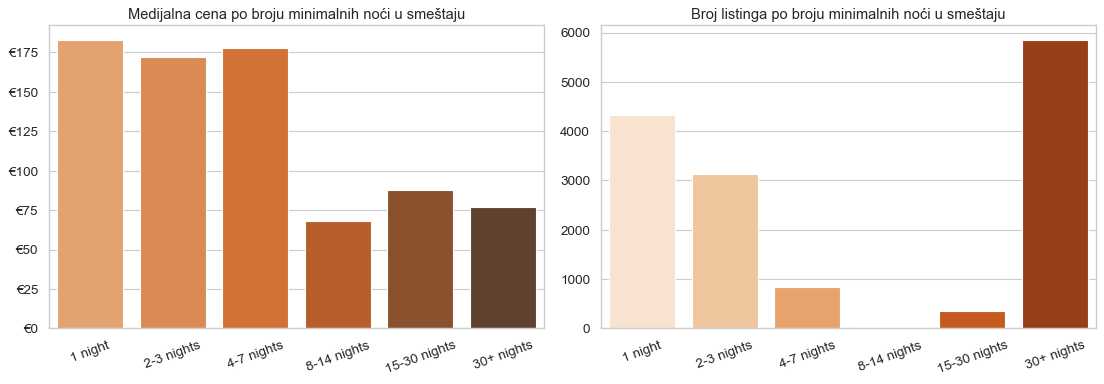

In [15]:
mn_stats = df.groupby('min_nights_bucket', observed=True)['price'].agg(
    Count='count', Mean='mean', Median='median'
).round(2)

display(mn_stats.style
    .background_gradient(subset=['Mean', 'Median'], cmap='Oranges')
    .format({'Mean': '€{:.2f}', 'Median': '€{:.2f}', 'Count': '{:,}'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=mn_stats.reset_index(), x='min_nights_bucket', y='Median',
            palette='Oranges_d', ax=axes[0])
axes[0].set_title('Medijalna cena po broju minimalnih noći u smeštaju')
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=20)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))

sns.barplot(data=mn_stats.reset_index(), x='min_nights_bucket', y='Count',
            palette='Oranges', ax=axes[1])
axes[1].set_title('Broj listinga po broju minimalnih noći u smeštaju')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 5. Cena po broju smeštaja istog domaćina


,Count,Mean,Median
host_size_bucket,,,
1 (Solo),"2,669",€120.40,€97.00
2-3,"2,082",€120.67,€90.00
4-10,"2,610",€161.15,€152.00
11-50,"3,845",€157.16,€145.00
50+ (Agency),"3,329",€143.26,€128.00


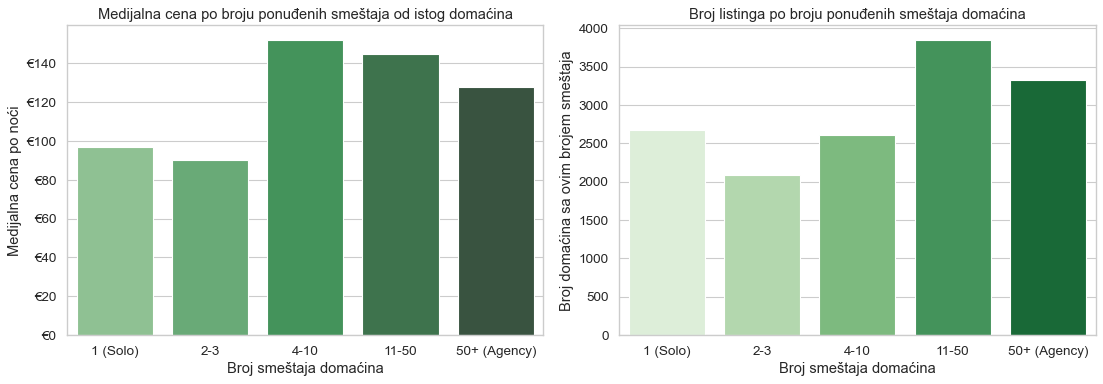

In [16]:
hs_stats = df.groupby('host_size_bucket', observed=True)['price'].agg(
    Count='count', Mean='mean', Median='median'
).round(2)

display(hs_stats.style
    .background_gradient(subset=['Mean', 'Median'], cmap='Greens')
    .format({'Mean': '€{:.2f}', 'Median': '€{:.2f}', 'Count': '{:,}'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=hs_stats.reset_index(), x='host_size_bucket', y='Median',
            palette='Greens_d', ax=axes[0])
axes[0].set_title('Medijalna cena po broju ponuđenih smeštaja od istog domaćina')
axes[0].set_xlabel('Broj smeštaja domaćina')
axes[0].set_ylabel('Medijalna cena po noći')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))

sns.barplot(data=hs_stats.reset_index(), x='host_size_bucket', y='Count',
            palette='Greens', ax=axes[1])
axes[1].set_title('Broj listinga po broju ponuđenih smeštaja domaćina')
axes[1].set_xlabel('Broj smeštaja domaćina')
axes[1].set_ylabel('Broj domaćina sa ovim brojem smeštaja')

plt.tight_layout()
plt.show()

## 6. Cena po broju recenzija


,Count,Mean,Median
reviews_bucket,,,
No reviews,"4,519",€112.80,€91.00
1-3,"3,060",€114.10,€87.00
4-10,"2,010",€141.65,€114.00
11-20,"1,264",€186.72,€183.00
21+,"3,682",€188.69,€184.00


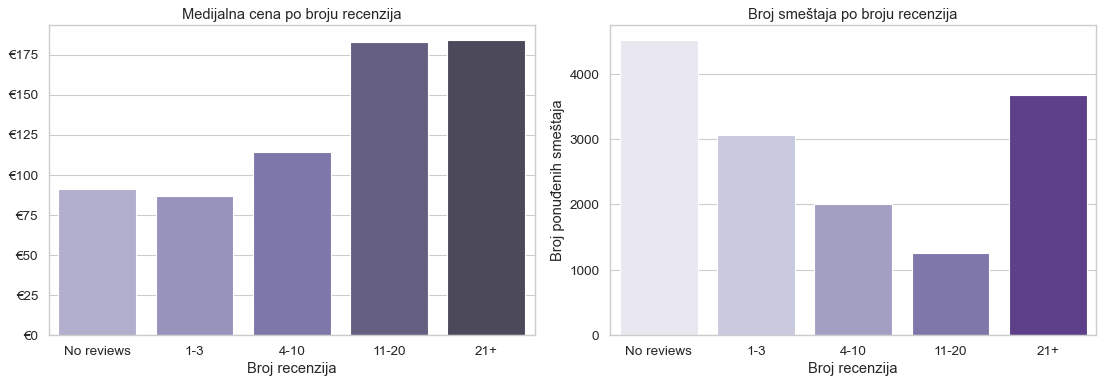

In [17]:
rv_stats = df.groupby('reviews_bucket', observed=True)['price'].agg(
    Count='count', Mean='mean', Median='median'
).round(2)

display(rv_stats.style
    .background_gradient(subset=['Mean', 'Median'], cmap='Purples')
    .format({'Mean': '€{:.2f}', 'Median': '€{:.2f}', 'Count': '{:,}'})
    
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=rv_stats.reset_index(), x='reviews_bucket', y='Median',
            palette='Purples_d', ax=axes[0])
axes[0].set_title('Medijalna cena po broju recenzija')
axes[0].set_xlabel('Broj recenzija')
axes[0].set_ylabel('')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))

sns.barplot(data=rv_stats.reset_index(), x='reviews_bucket', y='Count',
            palette='Purples', ax=axes[1])
axes[1].set_title('Broj smeštaja po broju recenzija')
axes[1].set_xlabel('Broj recenzija')
axes[1].set_ylabel('Broj ponuđenih smeštaja')

plt.tight_layout()
plt.show()

## 7. Medijalna cena po delu grada i vrsti sobe


,Entire home/apt,Hotel room,Private room,Shared room
Ciutat Vella,€101.00,€243.00,€73.00,€63.00
Eixample,€198.00,€181.00,€63.50,€46.00
Gràcia,€163.00,€203.50,€55.50,€39.50
Horta-Guinardó,€124.00,N/A,€45.00,N/A
Les Corts,€161.00,N/A,€59.00,€53.50
Nou Barris,€174.00,N/A,€45.00,N/A
Sant Andreu,€101.00,N/A,€54.50,€53.50
Sant Martí,€161.00,€312.00,€62.00,€43.00
Sants-Montjuïc,€152.00,€176.50,€55.00,€42.00
Sarrià-Sant Gervasi,€151.00,N/A,€51.00,€22.00


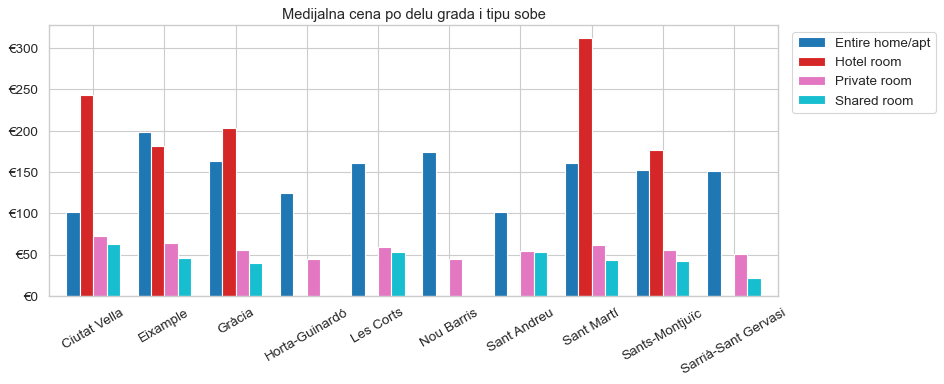

In [18]:
cross_district = df.pivot_table(
    values='price',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='median'
).round(2)
cross_district.index.name = None
cross_district.columns.name = None

display(cross_district.style
    .background_gradient(cmap='YlOrRd', axis=None)
    .format('€{:.2f}', na_rep='N/A')
)

fig, ax = plt.subplots(figsize=(12, 5))
cross_district.plot(kind='bar', ax=ax, colormap='tab10', width=0.75)
ax.set_title('Medijalna cena po delu grada i tipu sobe')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))
ax.legend(title='', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 9. Ridge Regression

Koristimo naše numeričke parametre

- **y** = log(price) — log-transformacija jer je raspodela cena asimetrična (desno nakošena)
- **X** = 12 features: tip sobe (one-hot), minimum noći, broj recenzija, veličina hosta, udaljenost od centra, broj gostiju, sobe, kreveti, kupatila, ocena
- **StandardScaler** — skaliranje svih features na mean=0, std=1 (potrebno da Ridge regularizacija tretira sve features jednako)
- **Split: 80% train / 10% validation / 10% test** — validation set se koristi za odabir najboljeg alpha, test set za finalnu evaluaciju
- **Ridge** — regularizovana linearna regresija; alpha se bira ručno na validation setu


In [19]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[numerical_cols].copy()
y = np.log(df['price'])   

# Train / validation / test split  80 / 10 / 10
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42    #   Uzmemo 20% pa ostane 80% za X_train
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42  #   Uzmemo 0.5 od X_temp koji je 20%, odnosno 10% dobijemo X_val i X_test 
)
print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

# Skaliramo sve parametre (posto npr udaljenost u km i broj recenzija nisu isti, previse se razlikuju, pa da ih napravimo sto slicnijim)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  #   Prvo treniramo, onda skaliramo
X_val_sc   = scaler.transform(X_val)    #   Samo skaliramo
X_test_sc  = scaler.transform(X_test)   #   Samo skaliramo

# Optimizacija hiperparametara, trazimo najbolji alfa koeficijent, velik alfa je velika kazna, malo alfa je mala kazna (ponasa se kao jednostavna linearna regresija)
alphas = [0.1, 1, 10, 100, 1000, 10000]    #   Probao sam i sa 0.0001 pa sve do 100000, dobijemo isti output, odnosno model ne overfit-uje, R² ostaje isti 
best_alpha, best_val_r2 = None, -np.inf
for alpha in alphas:
    m = Ridge(alpha=alpha)
    m.fit(X_train_sc, y_train) 
    val_r2 = r2_score(y_val, m.predict(X_val_sc))
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        best_alpha  = alpha
print(f'Best alpha: {best_alpha}  (val R²={best_val_r2:.3f})')


model = Ridge(alpha=best_alpha) #   Koristimo alfa koje smo u validation grupi izabrali
model.fit(X_train_sc, y_train)

y_pred_log = model.predict(X_test_sc)
y_pred_eur = np.exp(y_pred_log)
y_test_eur = np.exp(y_test)

mae  = mean_absolute_error(y_test_eur, y_pred_eur)
rmse = mean_squared_error(y_test_eur, y_pred_eur) ** 0.5
r2   = r2_score(y_test, y_pred_log)

print(f'\n{"Metric":<8} {"Value":>10}')
print('-' * 20)
print(f'{"MAE":<8} {"€"+f"{mae:.2f}":>10}')
print(f'{"RMSE":<8} {"€"+f"{rmse:.2f}":>10}')
print(f'{"R²":<8} {r2:>10.3f}')

# Compute coefficients for comparison chart (used in combined plot cell below)
coefs = pd.Series(model.coef_, index=numerical_cols).sort_values()

Train: 11,628  |  Val: 1,453  |  Test: 1,454
Best alpha: 0.1  (val R²=0.640)

Metric        Value
--------------------
MAE          €42.69
RMSE         €63.65
R²            0.611


## 10. Random Forest

Cilj: uporediti Random Forest sa Ridge Regression modelom na istim podacima.

- **Random Forest** — skup stabala odlučivanja; svako stablo uči na random podskupu podataka i parametara
- Za razliku od Ridge, može da uhvati **nelinearne veze** i **interakcije između parametara**
- Ne zahteva StandardScaler — stabla odlučivanja nisu osetljiva na skalu vrednosti
- Hiperparametri koje tražimo: `n_estimators` (broj stabala), `max_depth` (maksimalna dubina stabla)


In [20]:
from sklearn.ensemble import RandomForestRegressor

X_rf = df[numerical_cols].copy()
y_rf = np.log(df['price'])  #   Posto je velika razlika u average i median ceni smestaja, takodje cena ide od 9e - 480e, pa da je malo bolje grupisemo

# RF koristi sopstveni 80/20 train/test split, nezavisno od Ridge splitova
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)
print(f'RF Train: {len(X_rf_train):,}  |  RF Test: {len(X_rf_test):,}')

# Uzimamo najbolje parametre koje smo dobili sa grid search
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)


#param_grid = [
#{'n_estimators': n, 'max_depth': d, 'min_samples_leaf': l, 'max_features': f}
#for n in [300, 500]
#for d in [15, 20, 25, 30]
#for l in [1, 2, 5] 
#for f in ['sqrt', 0.5] 
#]

rf_model.fit(X_rf_train, y_rf_train)    

rf_pred_log = rf_model.predict(X_rf_test)   #   pretpostavljamo testni skup
rf_pred_eur = np.exp(rf_pred_log)   #   Posto je cena log
rf_test_eur = np.exp(y_rf_test)

rf_mae  = mean_absolute_error(rf_test_eur, rf_pred_eur)
rf_rmse = mean_squared_error(rf_test_eur, rf_pred_eur) ** 0.5
rf_r2   = r2_score(y_rf_test, rf_pred_log)

print(f'\n{"Metric":<8} {"Value":>10}')
print('-' * 20)
print(f'{"MAE":<8} {"€"+f"{rf_mae:.2f}":>10}')
print(f'{"RMSE":<8} {"€"+f"{rf_rmse:.2f}":>10}')
print(f'{"R²":<8} {rf_r2:>10.3f}')

baseline_preds = np.exp(rf_model.predict(X_rf_train))

pd_rows = []
for col in numerical_cols:
    X_perturbed = X_rf_train.copy()
    X_perturbed[col] += X_rf_train[col].std()
    perturbed_preds = np.exp(rf_model.predict(X_perturbed))
    pct_rf = ((perturbed_preds - baseline_preds) / baseline_preds * 100).mean()
    pd_rows.append({'Feature': col, 'pct': pct_rf})

pd_effects = pd.DataFrame(pd_rows).set_index('Feature')['pct'].sort_values()

RF Train: 11,628  |  RF Test: 2,907

Metric        Value
--------------------
MAE          €31.77
RMSE         €49.91
R²            0.778


## 11. Ispis svih parametara i njihov uticaj na cenu u oba modela

U tabeli ispod vidimo ispisane naše odabrane **numeričke parametre** i šta tačno predstavlja njihova jedna standardna devijacija, kako bismo lakše razumeli dijagrame za output naših modela - Ridge Regression i Random Forest.

Još jedan detalj, naši one-hot parametri (tip sobe) su boolean, dakle 0 ili 1. Zato mean i median vrednosti malo čudno izgledaju.


In [21]:
rows = []
for col in numerical_cols:
    mean      = df[col].mean()
    median    = df[col].median()
    std       = df[col].std()
    ridge_pct = (np.exp(model.coef_[numerical_cols.index(col)]) - 1) * 100
    rf_pct    = pd_effects[col]
    rows.append({
        'Feature':           col,
        'Mean':              round(mean, 2),
        'Median':            round(median, 2),
        '1 SD (real units)': round(std, 2),
        'Ridge effect (%)':  round(ridge_pct, 1),
        'RF effect (%)':     round(rf_pct, 1),
    })

interp = pd.DataFrame(rows).set_index('Feature').sort_values('Ridge effect (%)', ascending=False)
display(interp.style
    .background_gradient(subset=['Ridge effect (%)'], cmap='RdYlGn', vmin=-20, vmax=40)
    .background_gradient(subset=['RF effect (%)'],    cmap='RdYlGn', vmin=-20, vmax=40)
    .format({'Mean': '{:.2f}', 'Median': '{:.2f}', '1 SD (real units)': '{:.2f}',
             'Ridge effect (%)': '{:+.1f}%', 'RF effect (%)': '{:+.1f}%'})
    .set_caption('Uzimamo prosek i 1 standardnu devijaciju za svaki parametar.')
)

,Mean,Median,1 SD (real units),Ridge effect (%),RF effect (%)
Feature,,,,,
accommodates,3.41,3.00,1.94,+27.0%,+29.9%
room_Entire home/apt,0.68,1.00,0.47,+13.1%,-0.0%
review_scores_rating,4.62,4.71,0.45,+5.6%,+5.0%
calculated_host_listings_count,2.67,2.40,1.68,+3.0%,+8.4%
bathrooms,1.36,1.00,0.65,+2.8%,+0.2%
room_Hotel room,0.00,0.00,0.06,+2.4%,-0.0%
number_of_reviews,1.65,1.39,1.48,+0.2%,+5.3%
beds,2.35,2.00,1.93,-0.5%,+2.3%
bedrooms,1.73,1.00,1.04,-3.5%,+2.4%


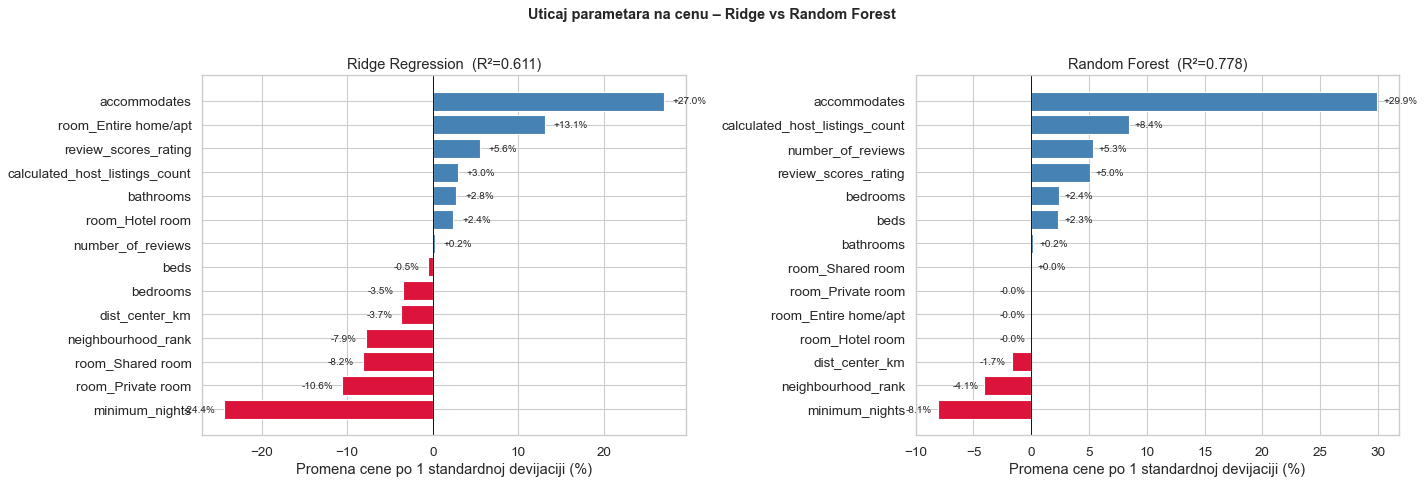

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Ridge 
ridge_pct = (np.exp(coefs) - 1) * 100
colors_ridge = ['crimson' if v < 0 else 'steelblue' for v in ridge_pct]
bars = axes[0].barh(ridge_pct.index, ridge_pct.values, color=colors_ridge)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f'Ridge Regression  (R²={r2:.3f})')
axes[0].set_xlabel('Promena cene po 1 standardnoj devijaciji (%)')
for bar, val in zip(bars, ridge_pct.values):
    axes[0].text(val + (1 if val >= 0 else -1), bar.get_y() + bar.get_height() / 2,
                 f'{val:+.1f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# Random Forest
colors_rf = ['crimson' if v < 0 else 'steelblue' for v in pd_effects]
bars = axes[1].barh(pd_effects.index, pd_effects.values, color=colors_rf)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title(f'Random Forest  (R²={rf_r2:.3f})')
axes[1].set_xlabel('Promena cene po 1 standardnoj devijaciji (%)')
for bar, val in zip(bars, pd_effects.values):
    axes[1].text(val + (0.5 if val >= 0 else -0.5), bar.get_y() + bar.get_height() / 2,
                 f'{val:+.1f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.suptitle('Uticaj parametara na cenu – Ridge vs Random Forest', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Poređenje modela Ridge Regression i Random Forest

Ridge Regression -> **R²** = 0.611, **MAE** = €42.69, **RMSE** = €63.65

Random Forest -> **R²** = 0.778, **MAE** = €31.77, **RMSE** = €49.91

**Ridge Regression** je linearan model koji pretpostavlja da svaki parametar ima konstantan i nezavisan uticaj na cenu (od ostalih parametara). Postiže R²=0.611, što znači da objašnjava malo više od 60% varijacije cene.

**Random Forest** postiže R²=0.766 jer može da uhvati nelinearne veze i interakcije između parametara — na primer, da veliki broj spavaćih soba ima veći uticaj na cenu blizu centra nego daleko od njega.

Dodali smo **ordinal_by_price** rankiranje dela grada, odnosno **neighbourhood_rank**, pošto u CSV ima 75 ovakvih kategorija, pa bi bilo previše parametara da smo koristili one-hot metod.

Random Forest je trenirao 80% podataka i 20% testni skup, što je možda poboljšalo rezultat u odnosu na Ridge koji koristi 80-10-10, validacioni skup nije bio mnogo koristan jer se menjanjem alfa parametra ne dobija velika razlika u rezultatu.
